In [1]:
import mysql.connector
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random
import warnings
warnings.filterwarnings('ignore')
def generate_sample_data():
    """Generate synthetic customer and transaction data without faker"""
    conn = mysql.connector.connect(
        host="localhost",
        user="root",  # Replace with your MySQL username
        password="Password123",  
        database="sales_analysis"
    )
    cursor = conn.cursor()

    try:
        cursor.execute("SET FOREIGN_KEY_CHECKS = 0")
        cursor.execute("TRUNCATE TABLE order_items")
        cursor.execute("TRUNCATE TABLE orders")
        cursor.execute("TRUNCATE TABLE customers")
        cursor.execute("TRUNCATE TABLE products")
        cursor.execute("SET FOREIGN_KEY_CHECKS = 1")
        print("✓ Cleared existing data")
    except:
        print("⚠️ Could not clear tables (they might not exist yet)")
    print("Generating customers...")
    
    first_names = ['John', 'Emma', 'Michael', 'Sophia', 'William', 'Olivia', 'James', 'Ava', 
                   'Robert', 'Isabella', 'David', 'Mia', 'Richard', 'Charlotte', 'Joseph', 
                   'Amelia', 'Thomas', 'Harper', 'Charles', 'Evelyn']
    
    last_names = ['Smith', 'Johnson', 'Williams', 'Brown', 'Jones', 'Garcia', 'Miller', 'Davis',
                  'Rodriguez', 'Martinez', 'Hernandez', 'Lopez', 'Wilson', 'Anderson', 'Thomas',
                  'Taylor', 'Moore', 'Jackson', 'Martin', 'Lee']
    
    cities = ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix', 'Philadelphia', 
              'San Antonio', 'San Diego', 'Dallas', 'Austin', 'Boston', 'Seattle', 'Denver',
              'Miami', 'Atlanta', 'Portland', 'Detroit', 'Memphis', 'Nashville', 'Baltimore']
    
    subscription_types = ['Basic', 'Premium', 'VIP']
    genders = ['Male', 'Female', 'Other']
    
    customers = []
    for i in range(200):
        first_name = random.choice(first_names)
        last_name = random.choice(last_names)
        name = f"{first_name} {last_name}"
        email = f"{first_name.lower()}.{last_name.lower()}@email.com"
        days_ago = random.randint(1, 730)
        join_date = datetime.now() - timedelta(days=days_ago)
        login_days_ago = random.randint(0, days_ago)
        last_login = datetime.now() - timedelta(days=login_days_ago)
        
        customers.append((
            name,
            email,
            join_date.date(),
            random.randint(18, 70),
            random.choice(genders),
            random.choice(cities),
            random.choice(subscription_types),
            last_login.date(),
            round(random.uniform(100, 5000), 2)
        ))
    cursor.executemany("""
        INSERT INTO customers (customer_name, email, join_date, age, gender, 
                              location, subscription_type, last_login_date, total_spent)
        VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s)
    """, customers)
    conn.commit()
    print(f"✓ Inserted {len(customers)} customers")
    print("Generating products...")
    
    products = [
        ('Laptop Pro', 'Electronics', 1299.99),
        ('Smartphone X', 'Electronics', 899.99),
        ('Wireless Headphones', 'Electronics', 199.99),
        ('Bluetooth Speaker', 'Electronics', 149.99),
        ('Smart Watch', 'Electronics', 299.99),
        ('Tablet', 'Electronics', 499.99),
        ('Gaming Mouse', 'Electronics', 79.99),
        ('Mechanical Keyboard', 'Electronics', 129.99),
        ('Cotton T-Shirt', 'Clothing', 29.99),
        ('Slim Fit Jeans', 'Clothing', 59.99),
        ('Leather Jacket', 'Clothing', 189.99),
        ('Running Shoes', 'Clothing', 129.99),
        ('Winter Coat', 'Clothing', 249.99),
        ('Fiction Novel', 'Books', 24.99),
        ('Cookbook', 'Books', 34.99),
        ('Business Book', 'Books', 29.99),
        ('Coffee Maker', 'Home', 149.99),
        ('Blender Pro', 'Home', 89.99),
        ('Air Fryer', 'Home', 199.99),
        ('Vacuum Cleaner', 'Home', 299.99)
    ]
    
    cursor.executemany("""
        INSERT INTO products (product_name, category, price)
        VALUES (%s, %s, %s)
    """, products)
    conn.commit()
    print(f"✓ Inserted {len(products)} products")
    cursor.execute("SELECT customer_id FROM customers")
    customer_ids = [row[0] for row in cursor.fetchall()]
    
    cursor.execute("SELECT product_id, price FROM products")
    product_data = cursor.fetchall()
    print("Generating orders...")
    orders = []
    order_items = []
    order_id_counter = 1
    
    start_date = datetime.now() - timedelta(days=730)  # 2 years ago
    end_date = datetime.now()
    
    for customer_id in customer_ids:
        num_orders = random.randint(3, 15)
        order_dates = []
        for _ in range(num_orders):
            # Random date within last 2 years
            days_range = (end_date - start_date).days
            random_days = random.randint(0, days_range)
            order_date = start_date + timedelta(days=random_days)
            order_dates.append(order_date)
        order_dates.sort()
        
        for order_date in order_dates:
            num_items = random.randint(1, 3)
            total_amount = 0
            for _ in range(num_items):
                product = random.choice(product_data)
                product_id = product[0]
                price = product[1]
                quantity = random.randint(1, 3)
                total_amount += price * quantity
                order_items.append((
                    order_id_counter,
                    product_id,
                    quantity,
                    price
                ))
            payment_method = random.choice(['Credit Card', 'PayPal', 'Debit Card', 'Cash'])
            status = random.choice(['Completed', 'Completed', 'Completed', 'Completed', 'Refunded'])
            
            orders.append((
                customer_id,
                order_date.date(),
                round(total_amount, 2),
                payment_method,
                status
            ))
            
            order_id_counter += 1
    if orders:
        cursor.executemany("""
            INSERT INTO orders (customer_id, order_date, total_amount, payment_method, order_status)
            VALUES (%s, %s, %s, %s, %s)
        """, orders)
        conn.commit()
        print(f"✓ Inserted {len(orders)} orders")
    
    # Insert order items
    if order_items:
        cursor.executemany("""
            INSERT INTO order_items (order_id, product_id, quantity, price_per_unit)
            VALUES (%s, %s, %s, %s)
        """, order_items)
        conn.commit()
        print(f"✓ Inserted {len(order_items)} order items")
    cursor.execute("""
        UPDATE customers c
        SET total_spent = (
            SELECT COALESCE(SUM(total_amount), 0)
            FROM orders o
            WHERE o.customer_id = c.customer_id
            AND o.order_status = 'Completed'
        )
    """)
    conn.commit()
    
    cursor.close()
    conn.close()
    
    print("\n✅ Sample data generation completed successfully!")
    print(f"   - Customers: {len(customers)}")
    print(f"   - Products: {len(products)}")
    print(f"   - Orders: {len(orders)}")
    print(f"   - Order Items: {len(order_items)}")

if __name__ == "__main__":
    generate_sample_data()


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\ProgramData\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\ProgramData\anaconda3\Lib\site-pack

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\ProgramData\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\ProgramData\anaconda3\Lib\site-pack

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\ProgramData\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\ProgramData\anaconda3\Lib\site-pack

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



✓ Cleared existing data
Generating customers...
✓ Inserted 200 customers
Generating products...
✓ Inserted 20 products
Generating orders...
✓ Inserted 1921 orders
✓ Inserted 3840 order items

✅ Sample data generation completed successfully!
   - Customers: 200
   - Products: 20
   - Orders: 1921
   - Order Items: 3840


🚀 Starting Customer Churn Analysis...

1. Loading data from MySQL...
   Loaded 200 customer records

2. Engineering features...
   ✓ Features created

3. Training churn prediction models...

TRAINING RANDOM FOREST MODEL

Performance Metrics:
              precision    recall  f1-score   support

           0       0.95      0.80      0.87        25
           1       0.74      0.93      0.82        15

    accuracy                           0.85        40
   macro avg       0.84      0.87      0.85        40
weighted avg       0.87      0.85      0.85        40

ROC-AUC Score: 0.933

Top 10 Important Features:
                    feature  importance
10   is_active_last_60_days    0.343316
9    is_active_last_30_days    0.123383
6   avg_days_between_orders    0.066280
1               total_spent    0.059275
7           order_frequency    0.057697
2              total_orders    0.055780
3             total_revenue    0.051384
5    customer_lifetime_days    0.051054
8         revenue_per_

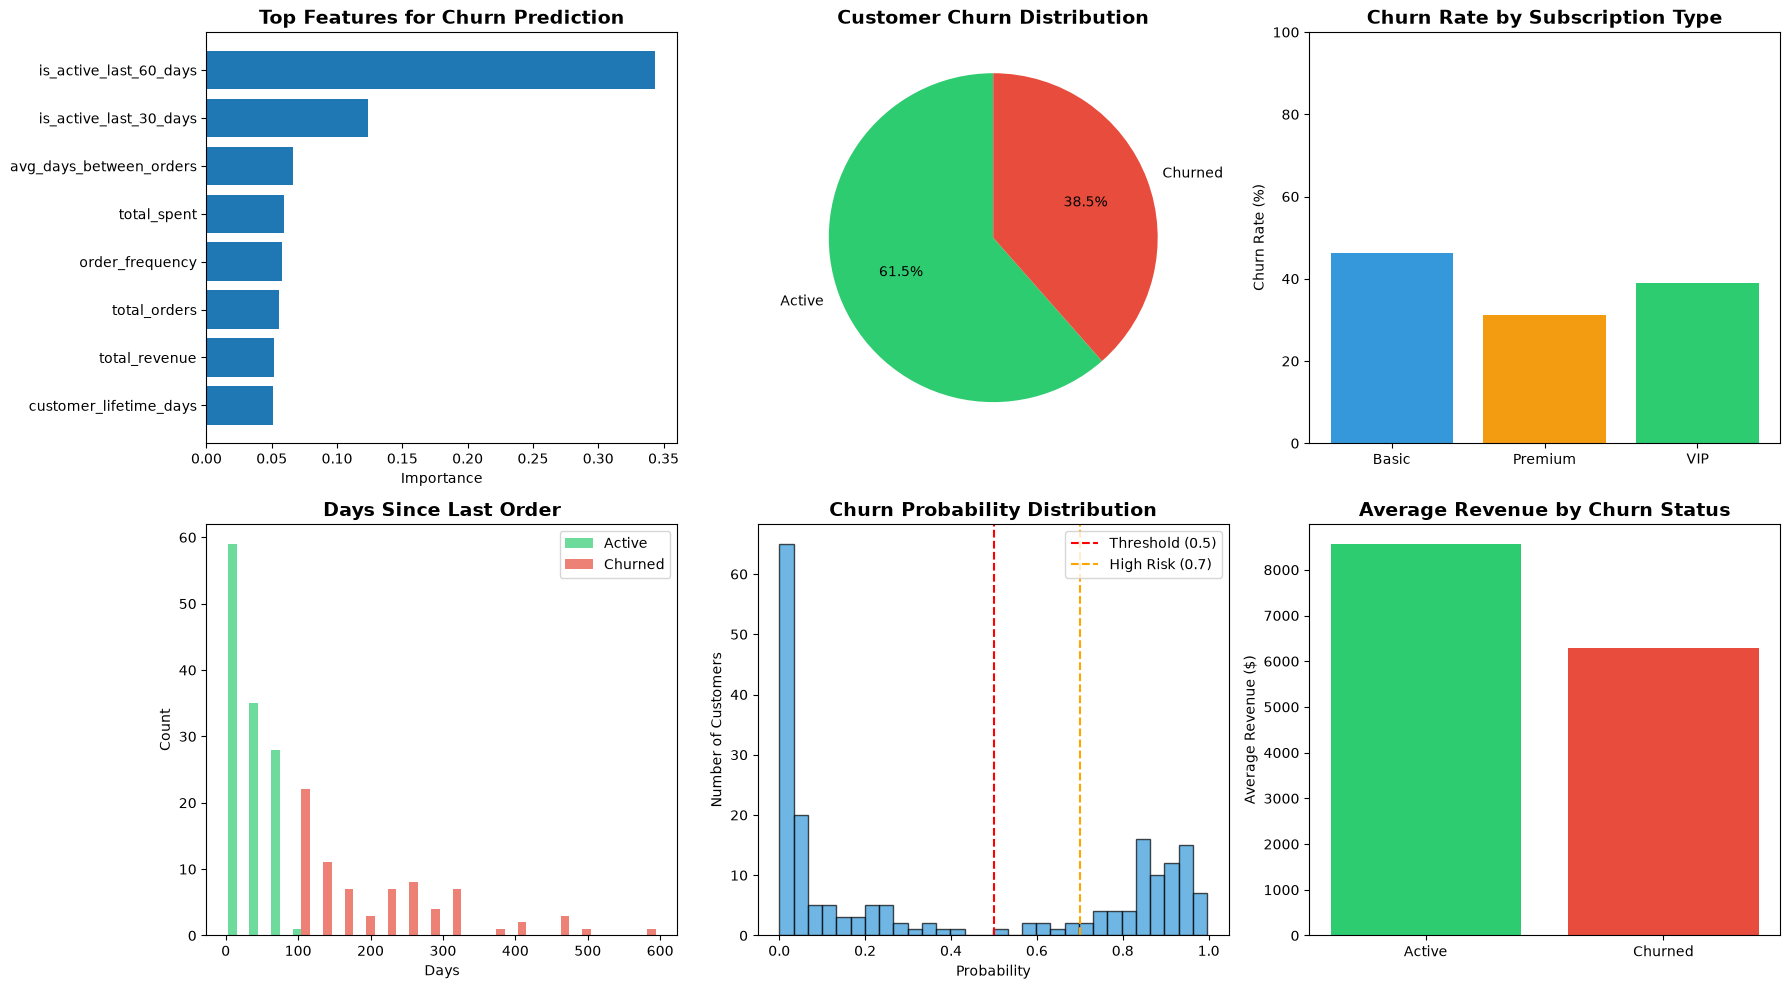


5. Generating report...

CUSTOMER CHURN ANALYSIS REPORT

📊 SUMMARY STATISTICS
----------------------------------------------------------------------
Total Customers: 200
Active Customers: 123
Churned Customers: 77
Overall Churn Rate: 38.5%
High-Risk Customers (Probability > 70%): 74

⚠️ TOP 10 HIGH-RISK CUSTOMERS
----------------------------------------------------------------------
    customer_name  churn_probability  days_since_last_order  total_spent subscription_type
     Robert Lopez           0.996667                    104      2544.83             Basic
  Charlotte Davis           0.990000                    269      2749.90           Premium
  Harper Anderson           0.988212                    132      7274.75             Basic
        Mia Lopez           0.973522                    210      5199.71             Basic
      Emma Garcia           0.969355                    156      2819.89               VIP
       Olivia Lee           0.966783                    375      82

In [2]:

import mysql.connector
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
def load_data_from_mysql():
    """Load customer data from MySQL database"""
    
    conn = mysql.connector.connect(
        host="localhost",
        user="root",  
        password="Password123",  
        database="sales_analysis"
    )
    
    query = """
    SELECT 
        c.customer_id,
        c.customer_name,
        c.join_date,
        c.age,
        c.gender,
        c.location,
        c.subscription_type,
        c.last_login_date,
        c.total_spent,
        COUNT(DISTINCT o.order_id) as total_orders,
        COALESCE(SUM(o.total_amount), 0) as total_revenue,
        COALESCE(AVG(o.total_amount), 0) as avg_order_value,
        MAX(o.order_date) as last_order_date,
        COALESCE(DATEDIFF(CURRENT_DATE, MAX(o.order_date)), 365) as days_since_last_order,
        COUNT(DISTINCT DATE_FORMAT(o.order_date, '%Y-%m')) as active_months,
        COALESCE(MIN(o.order_date), c.join_date) as first_order_date
    FROM customers c
    LEFT JOIN orders o ON c.customer_id = o.customer_id AND o.order_status = 'Completed'
    GROUP BY c.customer_id
    """
    
    df = pd.read_sql(query, conn)
    conn.close()
    
    return df

def engineer_features(df):
    """Create additional features for churn prediction"""
    
    # Convert to datetime
    df['join_date'] = pd.to_datetime(df['join_date'])
    df['last_login_date'] = pd.to_datetime(df['last_login_date'])
    df['last_order_date'] = pd.to_datetime(df['last_order_date'])
    df['first_order_date'] = pd.to_datetime(df['first_order_date'])
    
    df['churn'] = (df['days_since_last_order'] > 90).astype(int)
    
    df['customer_lifetime_days'] = (pd.Timestamp.now() - df['join_date']).dt.days

    df['days_since_first_order'] = (pd.Timestamp.now() - df['first_order_date']).dt.days
    df['order_frequency'] = df['total_orders'] / (df['customer_lifetime_days'] / 30)
    df['order_frequency'] = df['order_frequency'].replace([np.inf, -np.inf], 0).fillna(0)
    df['avg_days_between_orders'] = df['customer_lifetime_days'] / df['total_orders'].replace(0, 1)
    df['avg_days_between_orders'] = df['avg_days_between_orders'].replace([np.inf, -np.inf], 365).fillna(365)
    df['revenue_per_order'] = df['total_revenue'] / df['total_orders'].replace(0, 1)

    df['is_active_last_30_days'] = (df['days_since_last_order'] <= 30).astype(int)
    df['is_active_last_60_days'] = (df['days_since_last_order'] <= 60).astype(int)
    subscription_map = {'Basic': 1, 'Premium': 2, 'VIP': 3}
    df['subscription_value'] = df['subscription_type'].map(subscription_map).fillna(0)
    df['age_group'] = pd.cut(df['age'], bins=[0, 25, 35, 50, 100], labels=['Young', 'Adult', 'Middle', 'Senior'])
    categorical_cols = ['gender', 'location', 'subscription_type', 'age_group']
    
    for col in categorical_cols:
        # Convert to string to avoid categorical issues
        df[col] = df[col].astype(str)
        df[col] = df[col].fillna('Unknown')
        le = LabelEncoder()
        df[col + '_encoded'] = le.fit_transform(df[col])
    
    return df
def train_and_evaluate(df):
    """Train churn prediction models and evaluate performance"""
    features = ['age', 'total_spent', 'total_orders', 'total_revenue', 
                'avg_order_value', 'customer_lifetime_days', 'avg_days_between_orders',
                'order_frequency', 'revenue_per_order', 'is_active_last_30_days',
                'is_active_last_60_days', 'subscription_value',
                'gender_encoded', 'location_encoded', 'subscription_type_encoded', 'age_group_encoded']
    
    X = df[features]
    y = df['churn']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    print("\n" + "="*60)
    print("TRAINING RANDOM FOREST MODEL")
    print("="*60)
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
    rf_model.fit(X_train_scaled, y_train)
    rf_pred = rf_model.predict(X_test_scaled)
    rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]
    
    print("\nPerformance Metrics:")
    print(classification_report(y_test, rf_pred))
    print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_prob):.3f}")
    
    # Feature Importance
    feature_importance = pd.DataFrame({
        'feature': features,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\nTop 10 Important Features:")
    print(feature_importance.head(10))
    print("\n" + "="*60)
    print("TRAINING LOGISTIC REGRESSION MODEL")
    print("="*60)
    lr_model = LogisticRegression(random_state=42, max_iter=1000)
    lr_model.fit(X_train_scaled, y_train)
    lr_pred = lr_model.predict(X_test_scaled)
    lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]
    
    print("\nPerformance Metrics:")
    print(classification_report(y_test, lr_pred))
    print(f"ROC-AUC Score: {roc_auc_score(y_test, lr_prob):.3f}")
    df['churn_probability'] = rf_model.predict_proba(scaler.transform(X))[:, 1]
    high_risk = df[df['churn_probability'] > 0.7].sort_values('churn_probability', ascending=False)
    
    return df, high_risk, feature_importance, rf_model, scaler
def create_visualizations(df, feature_importance):
    """Create visualization dashboard"""
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    ax = axes[0, 0]
    top_features = feature_importance.head(8)
    ax.barh(top_features['feature'], top_features['importance'])
    ax.set_title('Top Features for Churn Prediction', fontsize=14, fontweight='bold')
    ax.set_xlabel('Importance')
    ax.invert_yaxis()
    ax = axes[0, 1]
    churn_counts = df['churn'].value_counts()
    colors = ['#2ecc71', '#e74c3c']
    ax.pie(churn_counts.values, labels=['Active', 'Churned'], 
           autopct='%1.1f%%', colors=colors, startangle=90)
    ax.set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')
    ax = axes[0, 2]
    churn_by_sub = df.groupby('subscription_type')['churn'].mean() * 100
    ax.bar(churn_by_sub.index, churn_by_sub.values, color=['#3498db', '#f39c12', '#2ecc71'])
    ax.set_title('Churn Rate by Subscription Type', fontsize=14, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, 100)
    ax = axes[1, 0]
    active = df[df['churn'] == 0]['days_since_last_order']
    churned = df[df['churn'] == 1]['days_since_last_order']
    ax.hist([active, churned], bins=20, label=['Active', 'Churned'], 
            alpha=0.7, color=['#2ecc71', '#e74c3c'])
    ax.set_title('Days Since Last Order', fontsize=14, fontweight='bold')
    ax.set_xlabel('Days')
    ax.set_ylabel('Count')
    ax.legend()
    ax = axes[1, 1]
    ax.hist(df['churn_probability'], bins=30, color='#3498db', alpha=0.7, edgecolor='black')
    ax.axvline(x=0.5, color='red', linestyle='--', label='Threshold (0.5)')
    ax.axvline(x=0.7, color='orange', linestyle='--', label='High Risk (0.7)')
    ax.set_title('Churn Probability Distribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('Probability')
    ax.set_ylabel('Number of Customers')
    ax.legend()
    ax = axes[1, 2]
    revenue_by_churn = df.groupby('churn')['total_revenue'].mean()
    ax.bar(['Active', 'Churned'], revenue_by_churn.values, color=['#2ecc71', '#e74c3c'])
    ax.set_title('Average Revenue by Churn Status', fontsize=14, fontweight='bold')
    ax.set_ylabel('Average Revenue ($)')
    
    plt.tight_layout()
    plt.show()
def generate_report(df, high_risk):
    """Generate churn prevention strategies report"""
    
    print("\n" + "="*70)
    print("CUSTOMER CHURN ANALYSIS REPORT")
    print("="*70)
    
    print("\n📊 SUMMARY STATISTICS")
    print("-"*70)
    print(f"Total Customers: {len(df)}")
    print(f"Active Customers: {len(df[df['churn'] == 0])}")
    print(f"Churned Customers: {len(df[df['churn'] == 1])}")
    print(f"Overall Churn Rate: {df['churn'].mean()*100:.1f}%")
    print(f"High-Risk Customers (Probability > 70%): {len(high_risk)}")
    print("\n⚠️ TOP 10 HIGH-RISK CUSTOMERS")
    print("-"*70)
    if len(high_risk) > 0:
        print(high_risk[['customer_name', 'churn_probability', 'days_since_last_order', 
                         'total_spent', 'subscription_type']].head(10).to_string(index=False))
    else:
        print("No high-risk customers found!")
    print("\n🎯 CHURN PREVENTION STRATEGIES")
    print("-"*70)
    
    strategies = [
        {
            'name': 'Re-engagement Campaign',
            'target': 'Customers with 30-60 days inactivity',
            'action': 'Send personalized email with discount offers',
            'impact': '15-20% reactivation rate'
        },
        {
            'name': 'Loyalty Program Enhancement',
            'target': 'Basic subscription customers',
            'action': 'Offer upgrade incentives with exclusive benefits',
            'impact': '25% reduction in Basic tier churn'
        },
        {
            'name': 'Personalized Recommendations',
            'target': 'All active customers',
            'action': 'Implement product recommendation engine',
            'impact': '20% increase in order frequency'
        },
        {
            'name': 'Customer Feedback Survey',
            'target': 'Customers with churn probability > 60%',
            'action': 'Send satisfaction survey with retention offers',
            'impact': '10-15% recovery rate'
        },
        {
            'name': 'VIP Retention Program',
            'target': 'VIP customers with decreasing activity',
            'action': 'Dedicated account manager and early access',
            'impact': '30% reduction in VIP churn'
        }
    ]
    
    for i, strategy in enumerate(strategies, 1):
        print(f"\n{i}. {strategy['name']}")
        print(f"   Target: {strategy['target']}")
        print(f"   Action: {strategy['action']}")
        print(f"   Expected Impact: {strategy['impact']}")

def save_predictions_to_db(df):
    """Save churn predictions back to database"""
    
    try:
        conn = mysql.connector.connect(
            host="localhost",
            user="root",
            password="your_password",
            database="sales_analysis"
        )
        cursor = conn.cursor()
        try:
            cursor.execute("ALTER TABLE customers ADD COLUMN churn_probability FLOAT")
        except:
            pass  
        for _, row in df.iterrows():
            cursor.execute("""
                UPDATE customers 
                SET churn_probability = %s 
                WHERE customer_id = %s
            """, (row['churn_probability'], row['customer_id']))
        
        conn.commit()
        cursor.close()
        conn.close()
        print("   ✓ Predictions saved to database")
    except Exception as e:
        print(f"   ⚠️ Could not save to database: {e}")

if __name__ == "__main__":
    
    print("🚀 Starting Customer Churn Analysis...")
    print("="*70)
    print("\n1. Loading data from MySQL...")
    df = load_data_from_mysql()
    print(f"   Loaded {len(df)} customer records")
    print("\n2. Engineering features...")
    df = engineer_features(df)
    print("   ✓ Features created")
    print("\n3. Training churn prediction models...")
    df, high_risk, feature_importance, rf_model, scaler = train_and_evaluate(df)
    print("\n4. Creating visualizations...")
    create_visualizations(df, feature_importance)
    print("\n5. Generating report...")
    generate_report(df, high_risk)
    print("\n6. Saving results...")
    high_risk.to_csv('high_risk_customers.csv', index=False)
    df[['customer_id', 'customer_name', 'churn_probability']].to_csv('customer_churn_scores.csv', index=False)
    print("   ✓ Results saved to CSV files")
    print("\n7. Saving predictions to database...")
    save_predictions_to_db(df)
    print("\n✅ Analysis Complete!")
    print("="*70)